# 14 — Final figures for the manuscript

Redraws Figure 4 (SHAP bee swarm, full page width, 12 predictors) and Figure 5 (month–year heat map labelled
"Improvement over persistence"). Reads the saved model and predictions only; nothing is refitted.
**Run:** after 11 and 09 · CPU · about 2 minutes. Overwrites `fig4_shap_beeswarm` and `fig5_month_year_skill`
in `revision/figures/`.

In [1]:
# --- Setup: Drive, paths, shared helpers -------------------------------------------------------
import os, sys, json, time, warnings, subprocess
warnings.filterwarnings('ignore')
try:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'shap', 'scienceplots',
                    'ephem', 'catboost', 'lightgbm'], check=False)
except Exception:
    pass
_BASE = os.environ.get('SARKOY_BASE', '/content/drive/MyDrive/windforecast_rev1/')
sys.path.insert(0, os.path.join(_BASE, 'revision'))
if not os.path.exists(os.path.join(_BASE, 'revision', 'revision_utils.py')):
    raise FileNotFoundError('Copy revision_utils.py into ' + os.path.join(_BASE, 'revision') + ' first.')
import revision_utils as ru
import numpy as np, pandas as pd, matplotlib.pyplot as plt
BASE, REV, IN_COLAB, FAST = ru.get_paths()
ru.set_style()
RES = ru.Results(REV)
RES.path = REV + 'results_14.json'
GPU = ru.has_gpu()
try:
    from IPython.display import display
except Exception:
    display = print
print('BASE:', BASE, '| REV:', REV, '| GPU:', GPU, '| FAST (smoke test):', FAST)
print(ru.log_versions(REV))


Mounted at /content/drive
BASE: /content/drive/MyDrive/windforecast_rev1/ | REV: /content/drive/MyDrive/windforecast_rev1/revision/ | GPU: True | FAST (smoke test): False
{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'sklearn': '1.6.1', 'scipy': '1.16.3', 'xgboost': '3.4.1', 'lightgbm': '4.6.0', 'catboost': '1.2.10', 'optuna': '5.0.0', 'shap': '0.52.0', 'statsmodels': '0.15.0', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'pyarrow': '23.0.1', 'ephem': '4.2.1', 'tensorflow': '2.20.0', 'gpu': True}


Loaded causal matrix: (2964, 564), 2016-11-19 -> 2024-12-30, observed targets: 2957
saved figure fig4_shap_beeswarm


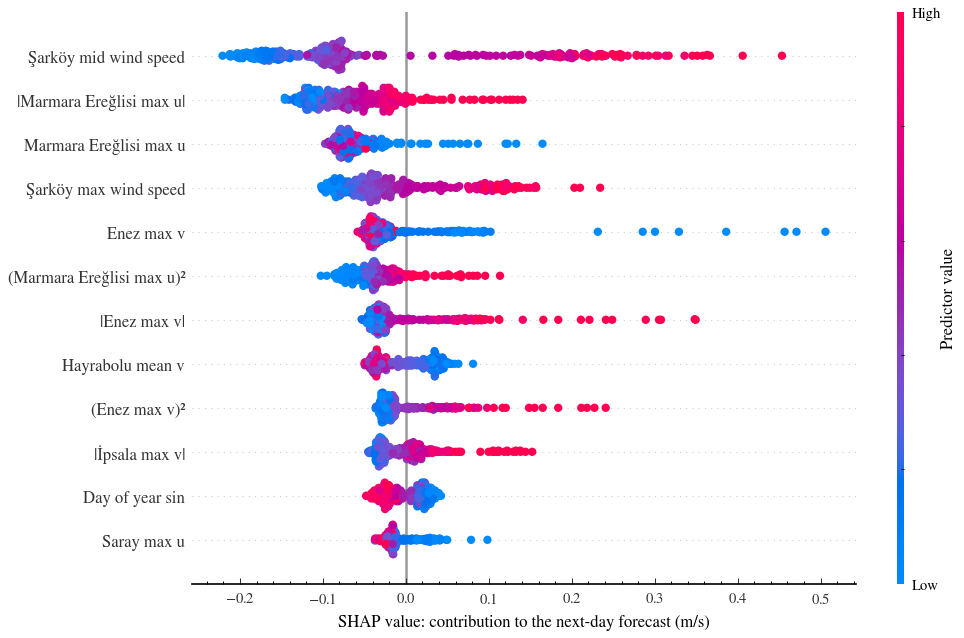

In [2]:
# --- Figure 4: SHAP bee swarm, full page width ------------------------------------------------------
import shap, xgboost as xgb
df = ru.load_matrix(BASE, REV, 'causal')
X = ru.get_X(df); y = df[ru.TARGET]; ok = df['target_observed'].astype(bool)
te = ok & (df.index.year == 2024)
model = xgb.XGBRegressor(); model.load_model(REV + 'models/xgb400_causal.json')
SV = shap.TreeExplainer(model).shap_values(X[te])
plt.rcParams.update({'font.size': 8})
shap.summary_plot(SV, X[te], feature_names=[ru.pretty(c) for c in X.columns], max_display=12, show=False,
                  plot_size=(7.0, 4.4), color_bar_label='Predictor value')
fig = plt.gcf(); ax = plt.gca()
ax.set_xlabel('SHAP value: contribution to the next-day forecast (m/s)', fontsize=8)
ax.tick_params(axis='y', labelsize=8); ax.tick_params(axis='x', labelsize=7)
cax = fig.axes[-1]
cax.set_ylabel('Predictor value', fontsize=8); cax.tick_params(labelsize=7)
fig.tight_layout(); ru.savefig(fig, REV, 'fig4_shap_beeswarm'); plt.show()


saved figure fig5_month_year_skill


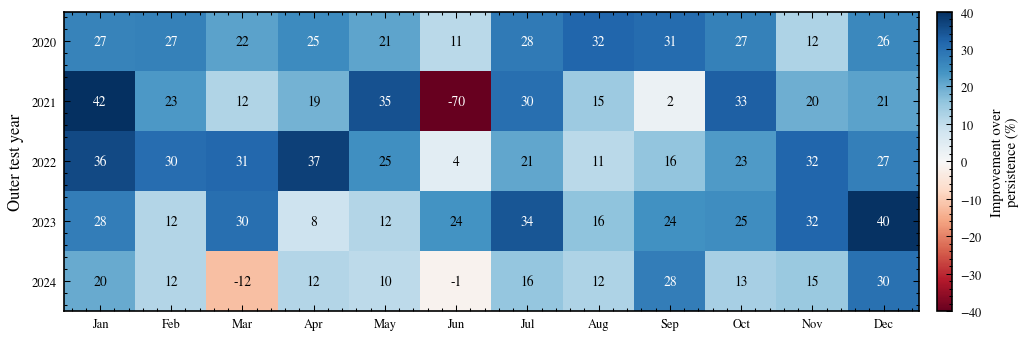

positive cells: 57 of 60


In [3]:
# --- Figure 5: month-year improvement over persistence ----------------------------------------------
R = pd.read_csv(REV + 'rolling_origin_predictions.csv', parse_dates=['date'])
R['month'] = R.date.dt.month
C = (R.groupby(['outer_year', 'month'])
       .apply(lambda g: 100 * (1 - ru.rmse(g.y_true, g.XGBoost_selected) / ru.rmse(g.y_true, g.persistence)), include_groups=False)
       .unstack('month'))
fig, ax = plt.subplots(figsize=(7.0, 2.4))
im = ax.imshow(C.values, cmap='RdBu', vmin=-40, vmax=40, aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticks(range(C.shape[0])); ax.set_yticklabels(C.index); ax.set_ylabel('Outer test year')
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        v = C.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6.5, color='white' if abs(v) > 25 else 'black')
cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02); cb.set_label('Improvement over\npersistence (%)', fontsize=7)
fig.tight_layout(); ru.savefig(fig, REV, 'fig5_month_year_skill'); plt.show()
print('positive cells:', int((C.values > 0).sum()), 'of', int(np.isfinite(C.values).sum()))
